# Підготовка набору даних для класифікації монет євро

Початковий набір даних призначений для детекції об'єктів: на одній фотографії може бути кілька монет, а їхнє положення задане у форматі YOLO. Для задачі багатокласової класифікації потрібно перетворити кожну розмічену монету на окреме зображення. На цьому етапі моделі ще не навчаються, оскільки спочатку важливо перевірити правильність кропів і розподіл класів.

## 1. Підключення модулів і визначення шляхів

У цьому блоці підключаються функції підготовки даних і візуалізації. Додавання кореня проєкту до `sys.path` потрібне для однакового запуску ноутбука як із кореневої папки, так і безпосередньо з каталогу `notebooks`. У результаті маємо перевірені шляхи до фотографій, розмітки та вихідних файлів.

In [1]:
from pathlib import Path
import sys
import warnings

# Визначаємо корінь проєкту незалежно від папки, з якої запущено Jupyter.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preparation import (
    CLASS_NAMES_UA,
    DatasetWarning,
    load_coin_dataset,
    print_dataset_summary,
    save_crop_examples,
)
from src.visualization import plot_class_distribution, plot_crop_grid

DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "labels"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Попередження залишаємо видимими, щоб не пропустити проблемний файл датасету.
warnings.simplefilter("always", DatasetWarning)

## 2. Зчитування YOLO-розмітки та вирізання монет

Для кожної фотографії знаходиться однойменний файл розмітки. Нормалізовані координати YOLO переводяться в пікселі з використанням фактичної ширини й висоти конкретного зображення. Після перевірки меж кожна монета вирізається та масштабується до `64x64` пікселів. Очікуваний результат цього блоку — список окремих RGB-зображень монет разом із класом, назвою вихідного файла та координатами рамки.

In [2]:
samples, report = load_coin_dataset(
    images_dir=IMAGES_DIR,
    labels_dir=LABELS_DIR,
    target_size=(64, 64),
)

print(f"Сформовано прикладів: {len(samples)}")
if samples:
    first_sample = samples[0]
    print(f"Розмір першого кропу: {first_sample.image.shape}")
    print(f"Клас першого кропу: {CLASS_NAMES_UA[first_sample.class_id]}")
    print(f"Вихідне зображення: {first_sample.source_image}")
    print(f"Піксельна рамка: {first_sample.bounding_box}")

Сформовано прикладів: 336
Розмір першого кропу: (64, 64, 3)
Клас першого кропу: 1 цент
Вихідне зображення: 001.jpg
Піксельна рамка: (348, 577, 480, 708)


## 3. Підсумкова перевірка набору

Тепер виводиться кількість вихідних фотографій, файлів анотацій, успішних кропів і класів. Окремий список лічильників показує, чи були відсутні файли, неправильні рядки або рамки за межами зображення. Таблиця розподілу потрібна, щоб одразу побачити дисбаланс між номіналами до майбутнього поділу на навчальну й тестову частини.

In [3]:
print_dataset_summary(samples, report)

Загальна кількість вихідних зображень: 150
Загальна кількість файлів розмітки: 150
Успішно вирізано об'єктів монет: 336
Кількість класів: 8

Розподіл об'єктів за класами:
ID класу   Номінал       Кількість
----------------------------------
0          1 cent               41
1          2 cent               51
2          5 cent               56
3          10 cent              32
4          20 cent              50
5          50 cent              27
6          1 euro               51
7          2 euro               28

Результати перевірок:
  Відсутні файли розмітки: 0
  Порожні файли розмітки: 0
  Некоректні рядки анотацій: 0
  Невідомі класи: 0
  Зображення, які не вдалося прочитати: 0
  Некоректні рамки: 0
  Рамки, обрізані до меж зображення: 0


## 4. Графік розподілу класів

Стовпчикова діаграма дає наочніше уявлення про кількість об'єктів кожного номіналу, ніж лише числова таблиця. Це важливо для подальшого вибору метрик і способу розбиття даних. У результаті очікується вісім стовпчиків із підписаною кількістю вирізаних монет.

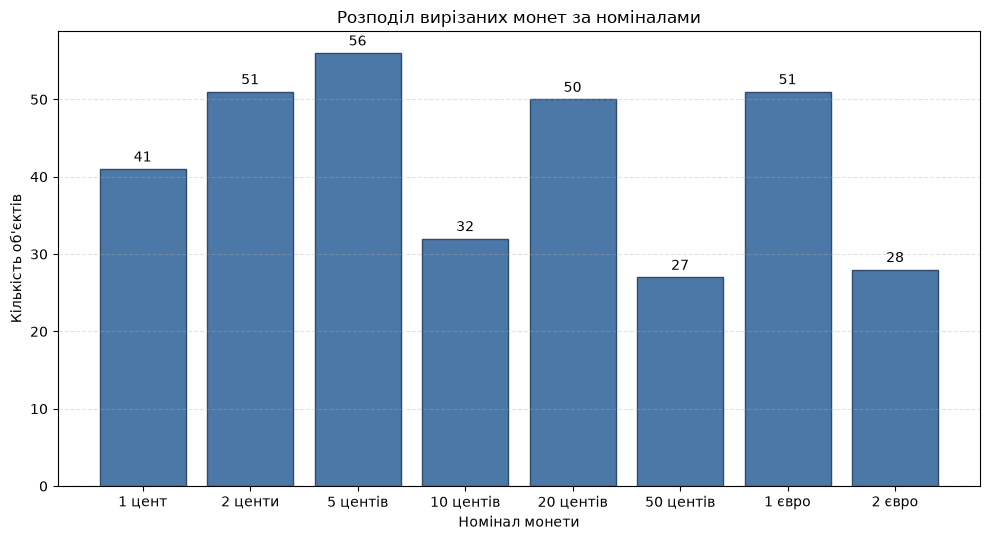

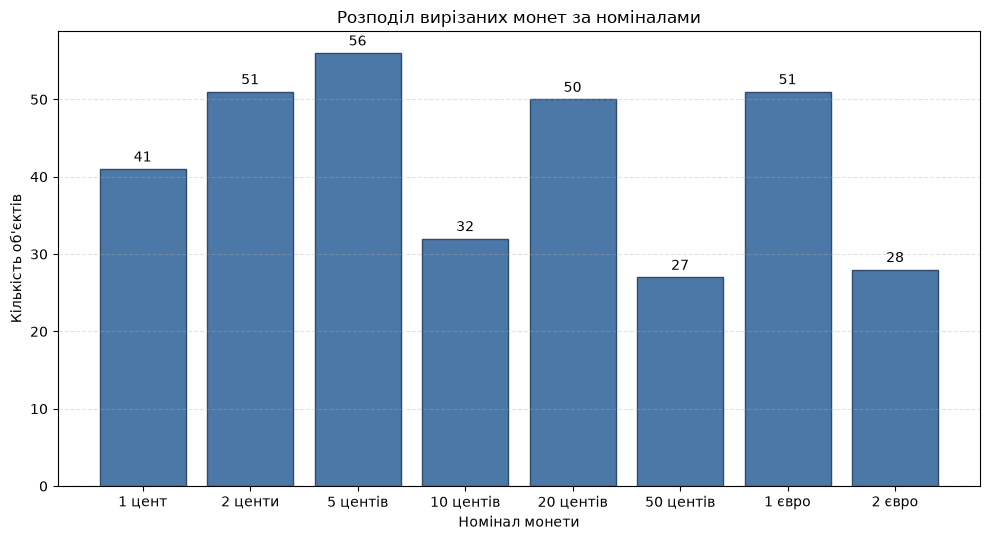

In [4]:
plot_class_distribution(
    samples,
    save_path=OUTPUT_DIR / "class_distribution.png",
    show=True,
)

## 5. Візуальна перевірка кропів

Одних координат недостатньо, щоб упевнитися в якості підготовки. Сітка показує по три приклади кожного класу та дозволяє перевірити, чи монета не обрізана, чи в кадр не потрапило забагато фону і чи відповідає зображення вказаному номіналу. Очікується вісім рядків, по одному для кожного класу.

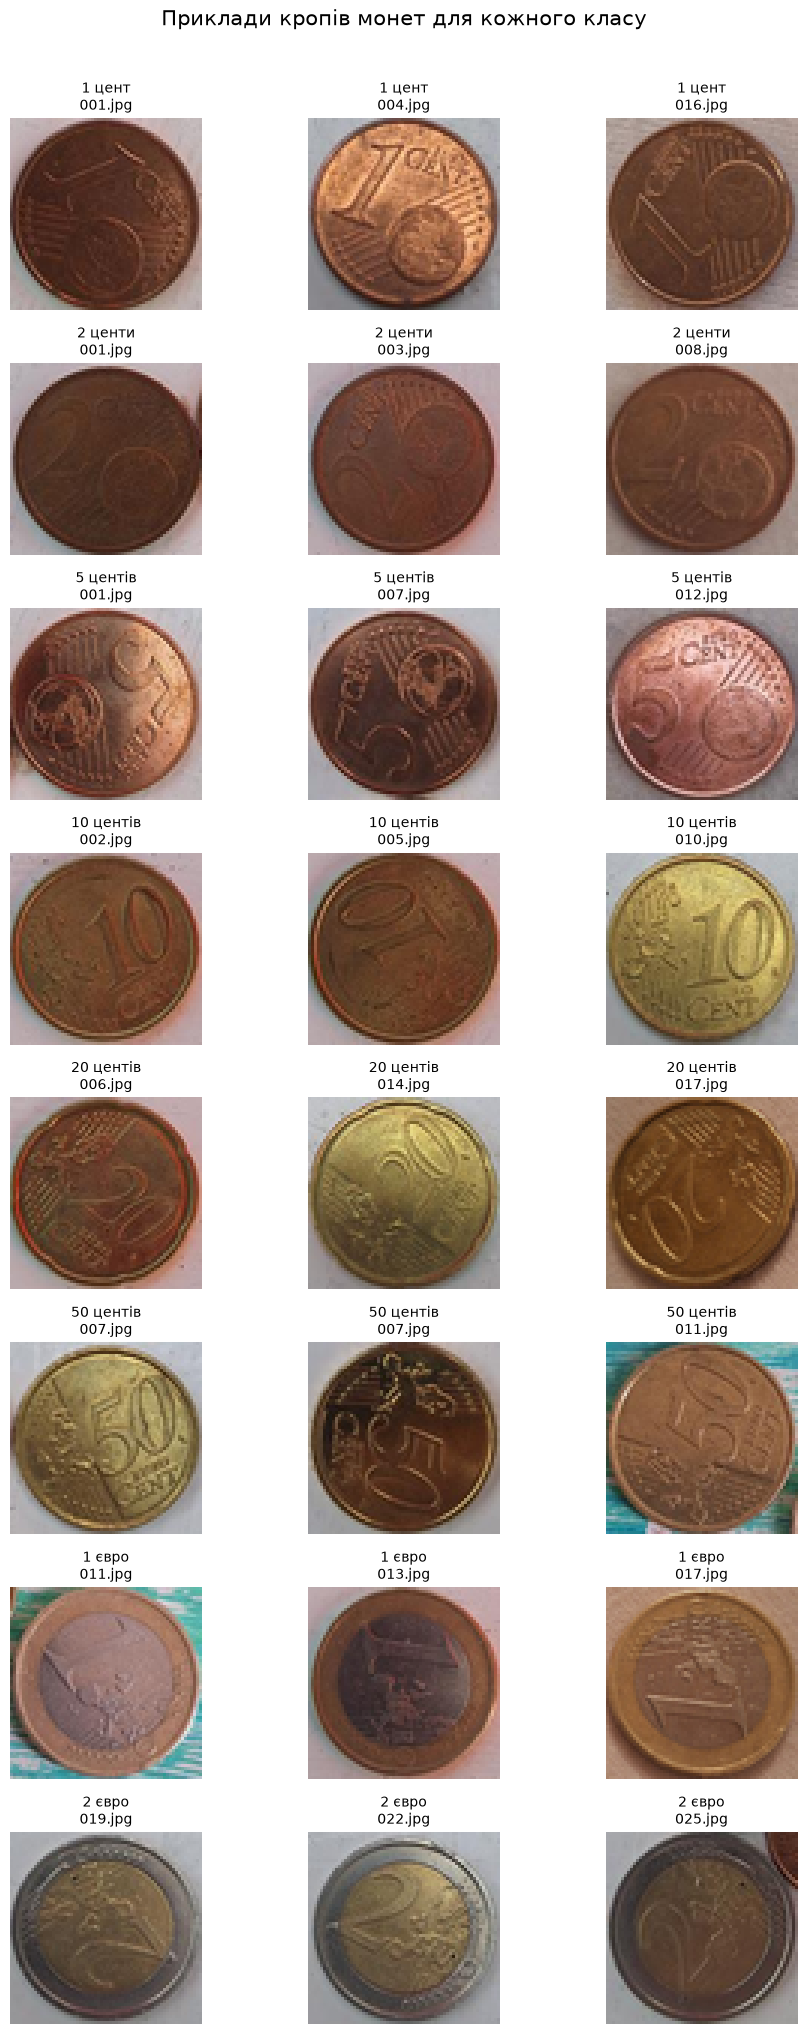

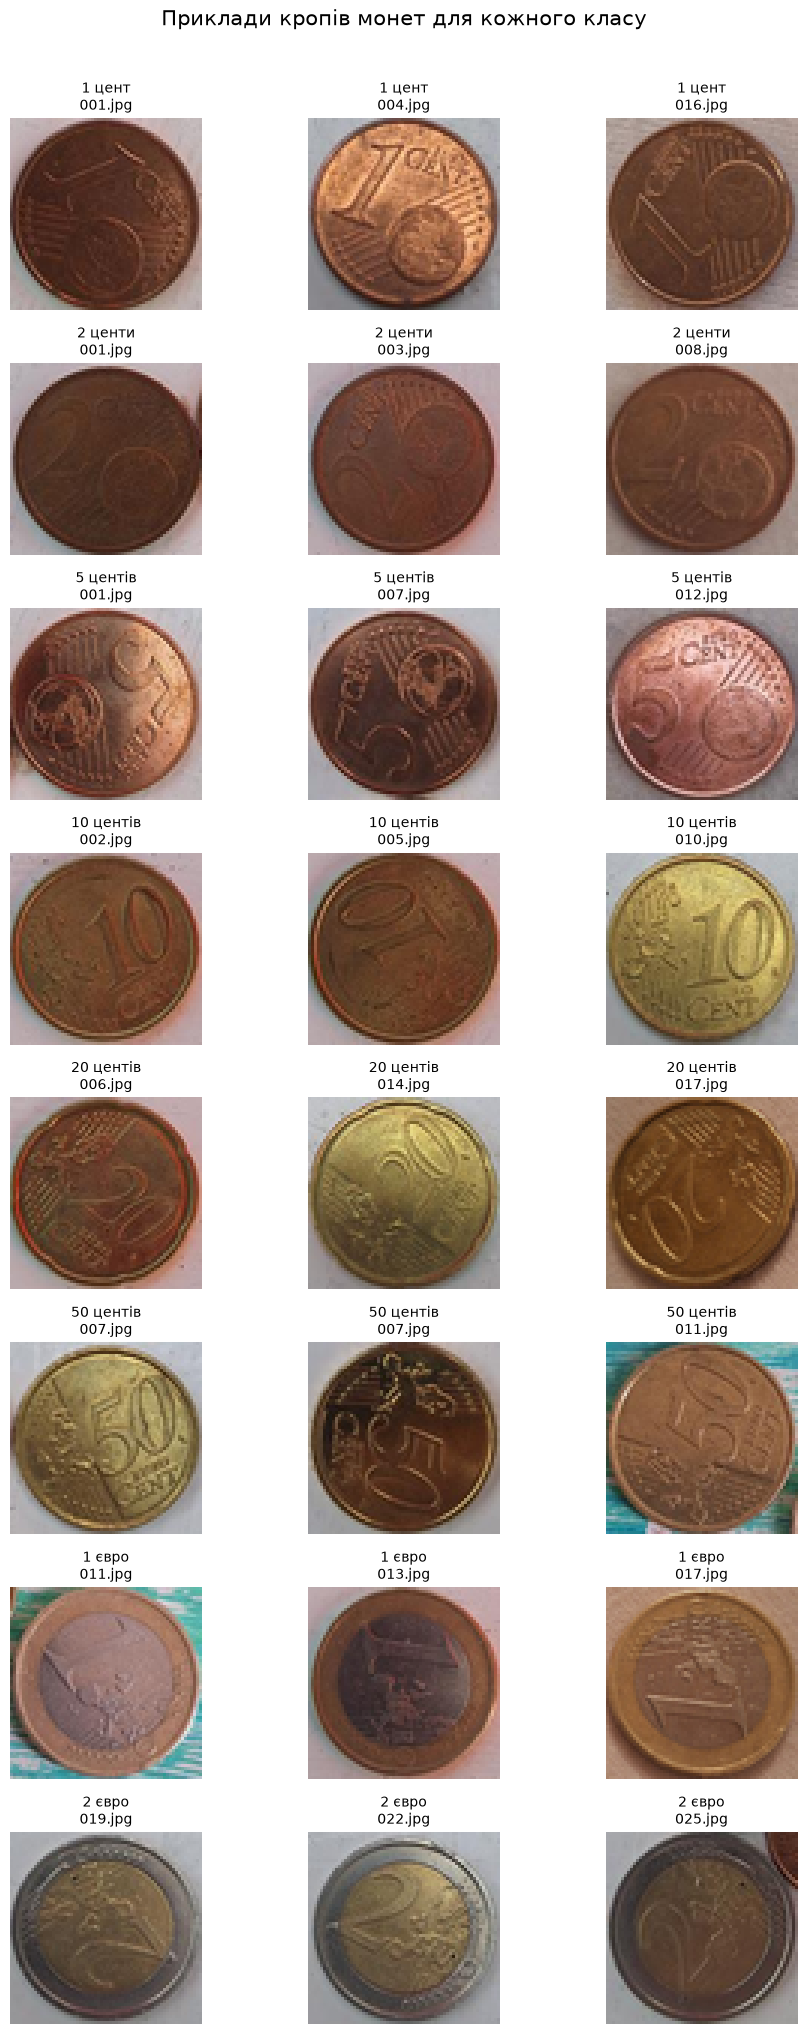

In [5]:
plot_crop_grid(
    samples,
    examples_per_class=3,
    save_path=OUTPUT_DIR / "crop_grid.png",
    show=True,
)

## 6. Збереження окремих контрольних прикладів

Кілька кропів кожного номіналу записуються як звичайні PNG-файли. Це дає змогу переглянути їх поза ноутбуком і переконатися, що масиви правильно перетворюються назад у зображення. У каталозі `outputs/crop_examples/` очікується до трьох файлів для кожного з восьми класів.

In [6]:
saved_paths = save_crop_examples(
    samples,
    output_dir=OUTPUT_DIR / "crop_examples",
    examples_per_class=3,
)

print(f"Збережено контрольних зображень: {len(saved_paths)}")

Збережено контрольних зображень: 24


## Висновок першого етапу

Після виконання всіх комірок YOLO-набір перетворено на набір окремих зображень для багатокласової класифікації. Кожен приклад має однаковий розмір `64x64`, ідентифікатор та назву класу, посилання на вихідну фотографію й піксельні координати рамки. Перед переходом до виділення ознак і навчання моделей потрібно переглянути збережену сітку та переконатися, що всі номінали вирізані коректно.

# Етап 2. Виділення ознак і підготовка даних

Класичні алгоритми машинного навчання не працюють безпосередньо із зображеннями як із картинками. Для них кожен кроп потрібно подати як набір чисел, тобто **ознак**. Ознака описує певну властивість об'єкта: яскравість окремого пікселя, напрямок краю, форму рельєфу або іншу вимірювану характеристику. На цьому етапі будуть побудовані два числові представлення: розгорнуті grayscale-пікселі та HOG-дескриптори.

## 7. Перетворення кропів у відтінки сірого

Колір монети залежить не лише від номіналу, а й від освітлення, камери та стану поверхні. Перехід до відтінків сірого зменшує кількість каналів із трьох до одного й дозволяє зосередитися на формі, цифрах та рельєфі. Значення кожного пікселя після перетворення лежить у діапазоні від 0 до 1. Очікується масив форми `(кількість монет, 64, 64)`.

In [7]:
from src.features import (
    check_feature_data,
    extract_feature_matrices,
    extract_hog_visualization,
    prepare_train_test_data,
    print_feature_checks,
)
from src.models import create_models, result_row, train_and_evaluate_model
from src.visualization import (
    plot_confusion_matrix, 
    plot_hog_example,
    plot_model_comparison,
)

# Одним проходом формуємо grayscale-зображення, raw pixels, HOG і цільові класи.
feature_set = extract_feature_matrices(samples)
print(f"Форма grayscale-масиву: {feature_set.grayscale_images.shape}")
print(f"Мінімальна яскравість: {feature_set.grayscale_images.min():.3f}")
print(f"Максимальна яскравість: {feature_set.grayscale_images.max():.3f}")

Форма grayscale-масиву: (336, 64, 64)
Мінімальна яскравість: 0.010
Максимальна яскравість: 1.000


## 8. Розгорнуті пікселі

Найпростіше числове представлення зображення — записати всі його пікселі в один довгий рядок. Для кропу `64x64` отримуємо `4096` ознак: спочатку значення першого рядка зображення, потім другого і так далі. Такий підхід зберігає всю інформацію про яскравість, але чутливий до невеликих зсувів, поворотів та змін освітлення. Він підготовлений для порівняння, проте основним представленням для моделей буде HOG.

In [8]:
print(f"Форма матриці розгорнутих пікселів: {feature_set.flattened_pixels.shape}")
print(f"Кількість числових ознак одного кропу: {feature_set.flattened_pixels.shape[1]}")

Форма матриці розгорнутих пікселів: (336, 4096)
Кількість числових ознак одного кропу: 4096


## 9. HOG-ознаки

HOG (Histogram of Oriented Gradients) ділить зображення на невеликі клітинки й підраховує, у яких напрямках у них найчастіше змінюється яскравість. Фактично дескриптор описує контури та напрямки країв, а не точні значення кожного пікселя. Для монет це корисно, тому що цифри номіналу, обідок і елементи карбування утворюють характерні лінії. HOG зазвичай стійкіший за raw pixels до помірних змін освітлення та невеликих локальних відмінностей.

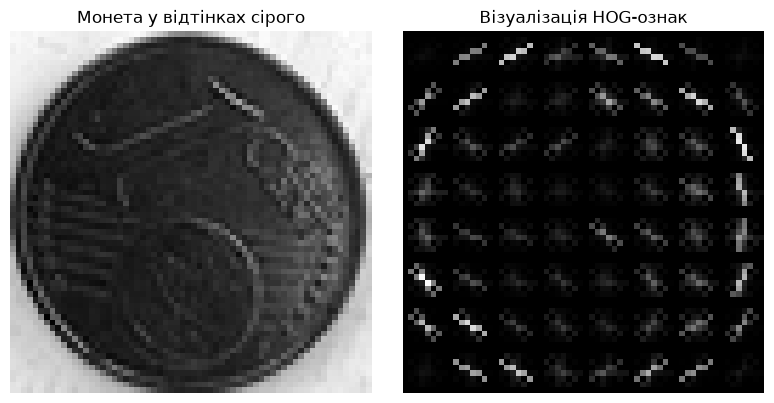

Кількість HOG-ознак для однієї монети: 1764


In [9]:
hog_image = extract_hog_visualization(feature_set.grayscale_images[0])
plot_hog_example(
    feature_set.grayscale_images[0],
    hog_image,
    save_path=OUTPUT_DIR / "hog_example.png",
    show=True,
);
print(f"Кількість HOG-ознак для однієї монети: {feature_set.hog_features.shape[1]}")

## 10. Матриця ознак `X` і цільовий вектор `y`

Рядок матриці `X` відповідає одній монеті, а кожен стовпець — одному числовому HOG-показнику. Вектор `y` містить правильний клас для кожного рядка. Перед навчанням перевіряються розміри, пропущені значення, повністю однакові рядки ознак і початковий розподіл класів. Це допомагає знайти технічні проблеми до того, як вони вплинуть на моделі.

In [10]:
# HOG обираємо основною матрицею ознак для всіх десяти моделей.
X = feature_set.hog_features
y = feature_set.targets

feature_checks = check_feature_data(X, y)
print_feature_checks(feature_checks)

Розмір матриці ознак X: (336, 1764)
Розмір цільового вектора y: (336,)
Пропущених значень у X: 0
Пропущених значень у y: 0
Повністю однакових рядків ознак: 0
Розподіл класів до поділу:
  0 (1 цент): 41
  1 (2 центи): 51
  2 (5 центів): 56
  3 (10 центів): 32
  4 (20 центів): 50
  5 (50 центів): 27
  6 (1 євро): 51
  7 (2 євро): 28


## 11. Кодування, нормалізація та поділ вибірки

`LabelEncoder` переводить мітки класів у послідовні цілі числа, зрозумілі алгоритмам. `StandardScaler` для кожної HOG-ознаки віднімає середнє та ділить на стандартне відхилення, тому ознаки отримують зіставний масштаб.

Нормалізація особливо важлива для **KNN**, бо він порівнює відстані між об'єктами; для **SVM**, бо масштаб впливає на положення розділювальної межі; для **логістичної регресії**, бо полегшує чисельну оптимізацію; для **MLPClassifier**, бо стабілізує та прискорює градієнтне навчання. Далі 20% об'єктів відводяться для тестування. `stratify=y_encoded` зберігає частки всіх восьми номіналів, а `random_state=42` робить поділ відтворюваним.

In [11]:
prepared_data = prepare_train_test_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Відповідність початкових і закодованих класів:")
for encoded_value, original_class in enumerate(prepared_data.label_encoder.classes_):
    print(f"  {CLASS_NAMES_UA[int(original_class)]}: {encoded_value}")

print(f"Форма навчальної матриці: {prepared_data.X_train.shape}")
print(f"Форма тестової матриці: {prepared_data.X_test.shape}")
print(f"Кількість навчальних міток: {prepared_data.y_train.shape[0]}")
print(f"Кількість тестових міток: {prepared_data.y_test.shape[0]}")

Відповідність початкових і закодованих класів:
  1 цент: 0
  2 центи: 1
  5 центів: 2
  10 центів: 3
  20 центів: 4
  50 центів: 5
  1 євро: 6
  2 євро: 7
Форма навчальної матриці: (268, 1764)
Форма тестової матриці: (68, 1764)
Кількість навчальних міток: 268
Кількість тестових міток: 68


# Етап 3. Навчання та оцінювання моделей

Для об'єктивного порівняння всі десять алгоритмів отримують однакові HOG-ознаки та той самий train/test split. Час вимірюється тільки для `fit`, а якість визначається на відкладеній тестовій вибірці. Крім загальної accuracy, для кожного класу виводяться precision, recall, F1-міра та матриця помилок.

## 12. Спільні функції експерименту

У цьому блоці створюються моделі та контейнери результатів. Допоміжна функція запускає навчання, зберігає прогноз у словнику `predictions`, додає рядок до майбутньої таблиці та будує heatmap. Обробка `try/except` потрібна, щоб помилка одного алгоритму не зупинила решту експерименту.

In [12]:
import numpy as np
import pandas as pd
from IPython.display import display

models = create_models(random_state=42)
class_names_ua = [
    CLASS_NAMES_UA[int(class_id)]
    for class_id in prepared_data.label_encoder.classes_
]

results_rows = []
predictions = {}
trained_models = {}
model_evaluations = {}
model_errors = {}


def run_notebook_model(model_name):
    # Навчаємо одну модель, показуємо метрики та зберігаємо результат.

    print(f"Початок навчання: {model_name}")
    try:
        evaluation = train_and_evaluate_model(
            model_name=model_name,
            model=models[model_name],
            X_train=prepared_data.X_train,
            y_train=prepared_data.y_train,
            X_test=prepared_data.X_test,
            y_test=prepared_data.y_test,
            class_names=class_names_ua,
        )
    except Exception as error:
        model_errors[model_name] = str(error)
        print(f"Помилка під час навчання моделі «{model_name}»: {error}")
        return None

    predictions[model_name] = evaluation.predictions
    trained_models[model_name] = evaluation.model
    model_evaluations[model_name] = evaluation
    results_rows.append(result_row(evaluation))

    print(f"Час навчання: {evaluation.training_time:.4f} с")
    print(f"Точність на тестовій вибірці: {evaluation.accuracy:.4f}")
    print("Класифікаційний звіт:")
    display(evaluation.classification_report.round(3))

    model_number = list(models).index(model_name) + 1
    plot_confusion_matrix(
        evaluation.confusion_matrix,
        class_names_ua,
        model_name,
        save_path=OUTPUT_DIR / "confusion_matrices" / f"model_{model_number:02d}.png",
        show=True,
    )
    return evaluation

## 13. LogisticRegression — логістична регресія

Логістична регресія будує лінійні межі між класами та перетворює їхні оцінки на ймовірності. Для багатокласової задачі модель одночасно порівнює всі номінали. Це хороший базовий метод: він швидкий, відтворюваний і показує, наскільки класи вже розділяються лінійною комбінацією HOG-ознак. Збільшений `max_iter` дає оптимізатору достатньо кроків для збіжності.

Початок навчання: Логістична регресія


Час навчання: 3.4056 с
Точність на тестовій вибірці: 0.8529
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.875,0.875,0.875,8.000
2 центи,0.900,0.900,0.900,10.000
5 центів,0.909,0.909,0.909,11.000
10 центів,0.714,0.714,0.714,7.000
20 центів,0.727,0.800,0.762,10.000
50 центів,0.800,0.667,0.727,6.000
1 євро,1.000,0.900,0.947,10.000
2 євро,0.857,1.000,0.923,6.000
загальна точність,0.853,0.853,0.853,0.853
макросереднє,0.848,0.846,0.845,68.000


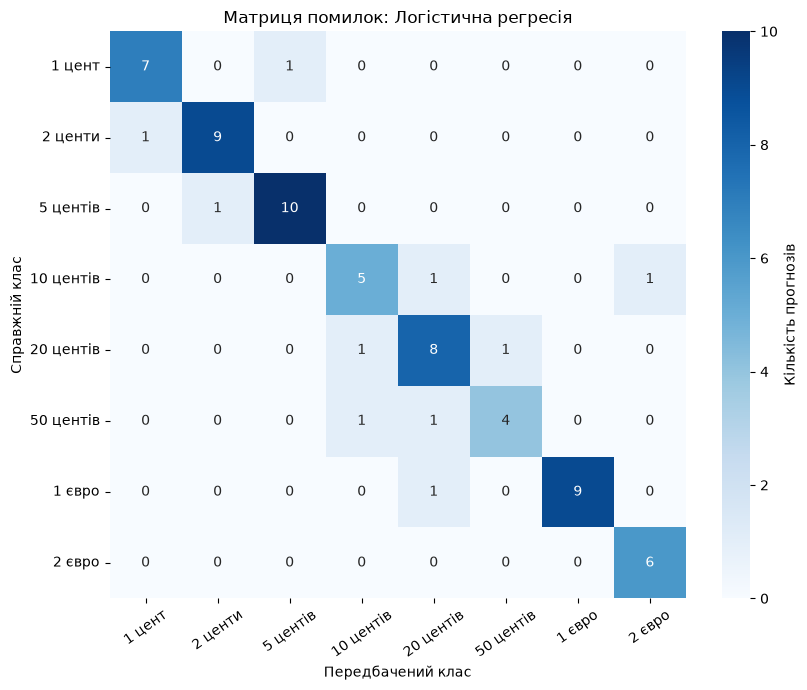

In [13]:
_ = run_notebook_model("Логістична регресія")

## 14. KNeighborsClassifier — метод k-найближчих сусідів

KNN не будує явної математичної моделі, а шукає у навчальній вибірці п'ять найближчих об'єктів. Прогноз визначається голосуванням їхніх класів. Метод добре працює, коли монети одного номіналу утворюють компактні групи в просторі HOG-ознак, але сильно залежить від правильного масштабування відстаней.

Початок навчання: Метод k-найближчих сусідів
Час навчання: 0.0008 с
Точність на тестовій вибірці: 0.7353
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.583,0.875,0.700,8.000
2 центи,1.000,0.800,0.889,10.000
5 центів,0.909,0.909,0.909,11.000
10 центів,0.714,0.714,0.714,7.000
20 центів,0.667,0.600,0.632,10.000
50 центів,1.000,0.500,0.667,6.000
1 євро,0.625,1.000,0.769,10.000
2 євро,0.500,0.167,0.250,6.000
загальна точність,0.735,0.735,0.735,0.735
макросереднє,0.750,0.696,0.691,68.000


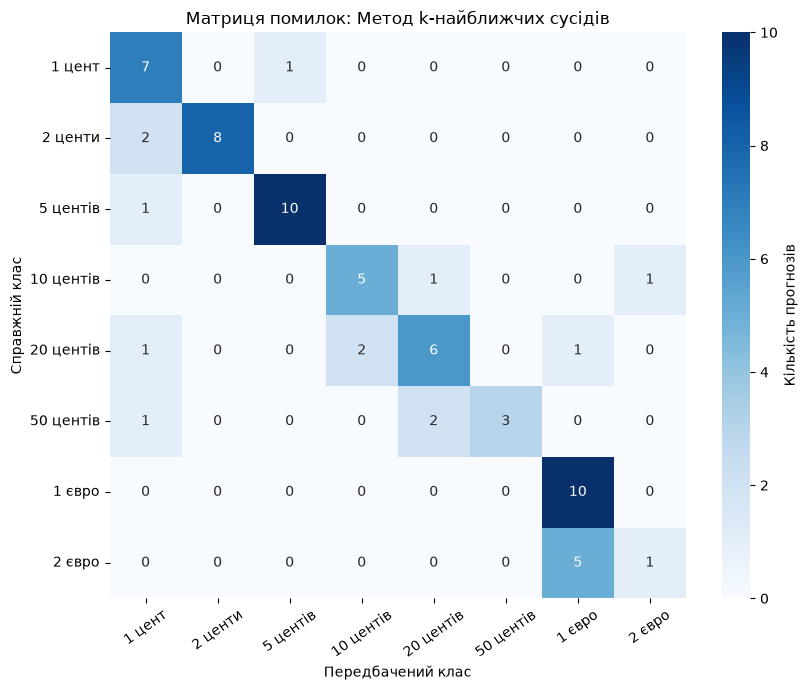

In [14]:
_ = run_notebook_model("Метод k-найближчих сусідів")

## 15. SVC — метод опорних векторів

SVC шукає межі з якомога більшим відступом між класами. Радіально-базисне RBF-ядро дозволяє будувати нелінійні межі, що корисно для складних відмінностей у рельєфі монет. На невеликому наборі даних цей метод часто показує сильний результат, хоча навчання може бути повільнішим за лінійні алгоритми.

Початок навчання: Метод опорних векторів
Час навчання: 0.0308 с
Точність на тестовій вибірці: 0.7647
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,1.000,0.875,0.933,8.000
2 центи,0.900,0.900,0.900,10.000
5 центів,0.769,0.909,0.833,11.000
10 центів,1.000,0.286,0.444,7.000
20 центів,0.526,1.000,0.690,10.000
50 центів,1.000,0.333,0.500,6.000
1 євро,0.750,0.900,0.818,10.000
2 євро,1.000,0.500,0.667,6.000
загальна точність,0.765,0.765,0.765,0.765
макросереднє,0.868,0.713,0.723,68.000


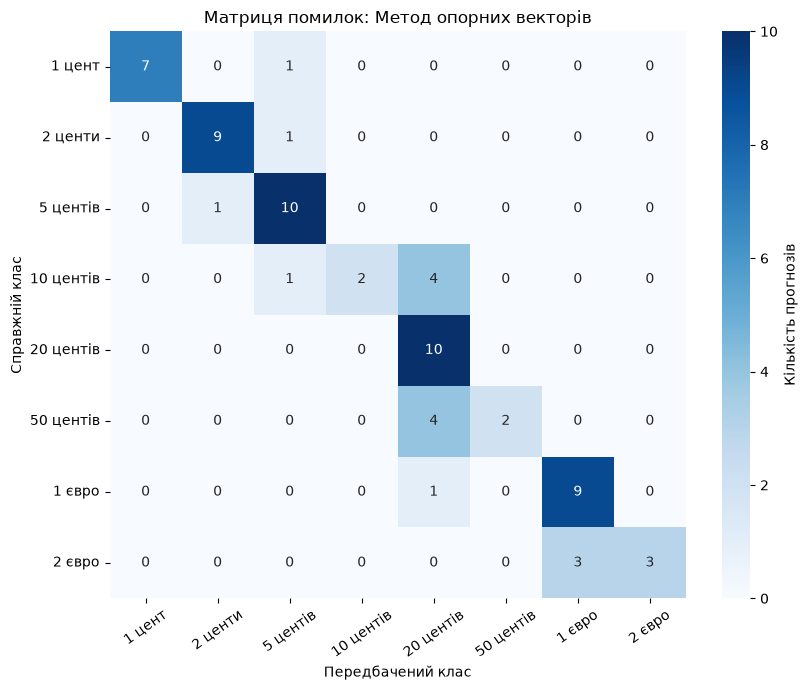

In [15]:
_ = run_notebook_model("Метод опорних векторів")

## 16. DecisionTreeClassifier — дерево рішень

Дерево рішень послідовно ділить простір ознак за умовами на окремі гілки. Кожен поділ обирається так, щоб краще відокремити класи. Модель легко інтерпретувати, але одне глибоке дерево може пристосуватися до випадкових особливостей навчальної вибірки й гірше узагальнювати нові фотографії.

Початок навчання: Дерево рішень
Час навчання: 0.1259 с
Точність на тестовій вибірці: 0.4265
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.556,0.625,0.588,8.000
2 центи,0.500,0.400,0.444,10.000
5 центів,0.200,0.182,0.190,11.000
10 центів,0.333,0.571,0.421,7.000
20 центів,0.333,0.300,0.316,10.000
50 центів,0.400,0.667,0.500,6.000
1 євро,0.714,0.500,0.588,10.000
2 євро,0.667,0.333,0.444,6.000
загальна точність,0.426,0.426,0.426,0.426
макросереднє,0.463,0.447,0.437,68.000


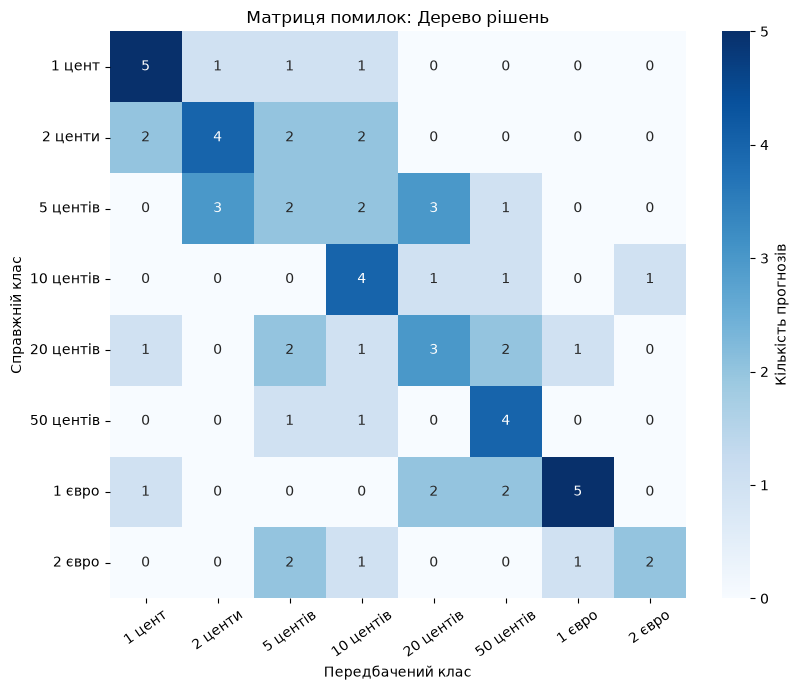

In [16]:
_ = run_notebook_model("Дерево рішень")

## 17. RandomForestClassifier — випадковий ліс

Випадковий ліс навчає багато дерев на різних підвибірках об'єктів та ознак, а потім об'єднує їхні голоси. Усереднення зменшує перенавчання окремого дерева й робить прогноз стабільнішим. Фіксований `random_state` забезпечує повторюваність результату.

Початок навчання: Випадковий ліс


Час навчання: 0.2102 с
Точність на тестовій вибірці: 0.7500
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.750,0.750,0.750,8.00
2 центи,0.818,0.900,0.857,10.00
5 центів,0.688,1.000,0.815,11.00
10 центів,1.000,0.429,0.600,7.00
20 центів,0.636,0.700,0.667,10.00
50 центів,1.000,0.500,0.667,6.00
1 євро,0.714,1.000,0.833,10.00
2 євро,1.000,0.333,0.500,6.00
загальна точність,0.750,0.750,0.750,0.75
макросереднє,0.826,0.701,0.711,68.00


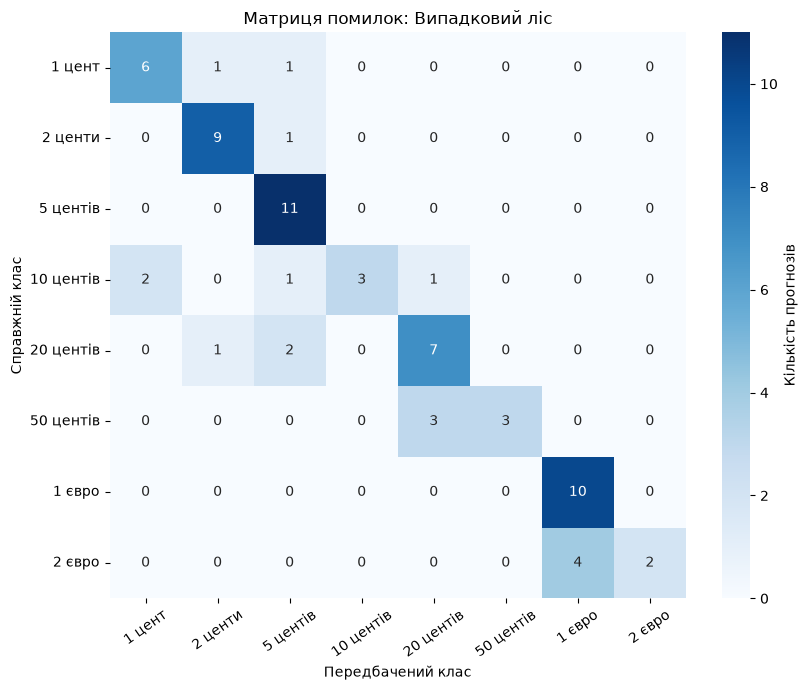

In [17]:
_ = run_notebook_model("Випадковий ліс")

## 18. ExtraTreesClassifier — надзвичайно рандомізовані дерева

Extra Trees також є ансамблем дерев, але пороги поділу вибираються більш випадково, ніж у випадковому лісі. Це додатково зменшує схожість між деревами та часто прискорює навчання. Порівняння з Random Forest покаже, чи корисна така сильніша рандомізація для HOG-описів монет.

Початок навчання: Надзвичайно рандомізовані дерева
Час навчання: 0.1402 с
Точність на тестовій вибірці: 0.7794
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.857,0.750,0.800,8.000
2 центи,0.692,0.900,0.783,10.000
5 центів,0.818,0.818,0.818,11.000
10 центів,1.000,0.571,0.727,7.000
20 центів,0.667,0.800,0.727,10.000
50 центів,1.000,0.667,0.800,6.000
1 євро,0.714,1.000,0.833,10.000
2 євро,1.000,0.500,0.667,6.000
загальна точність,0.779,0.779,0.779,0.779
макросереднє,0.844,0.751,0.769,68.000


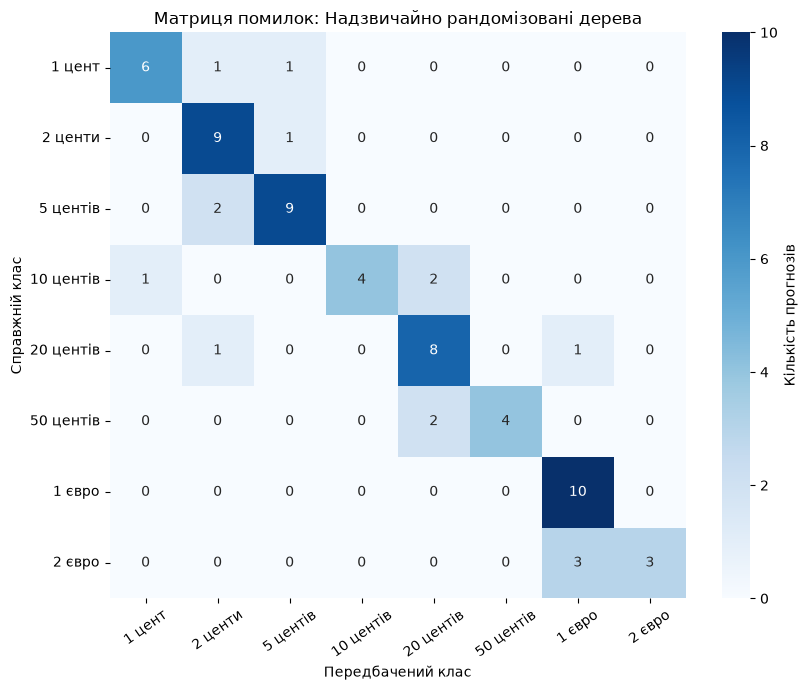

In [18]:
_ = run_notebook_model("Надзвичайно рандомізовані дерева")

## 19. GradientBoostingClassifier — градієнтний бустинг

Градієнтний бустинг будує дерева послідовно: кожне наступне намагається виправити помилки вже створеного ансамблю. Метод може знаходити складні нелінійні залежності, але потребує більше часу, бо дерева не можна навчити незалежно. Кількість оцінювачів обмежена, щоб експеримент залишався придатним для звичайного ноутбука.

Початок навчання: Градієнтний бустинг


Час навчання: 23.4908 с
Точність на тестовій вибірці: 0.6471
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,1.000,0.875,0.933,8.000
2 центи,0.833,0.500,0.625,10.000
5 центів,0.526,0.909,0.667,11.000
10 центів,0.500,0.571,0.533,7.000
20 центів,0.500,0.400,0.444,10.000
50 центів,0.571,0.667,0.615,6.000
1 євро,0.750,0.900,0.818,10.000
2 євро,1.000,0.167,0.286,6.000
загальна точність,0.647,0.647,0.647,0.647
макросереднє,0.710,0.624,0.615,68.000


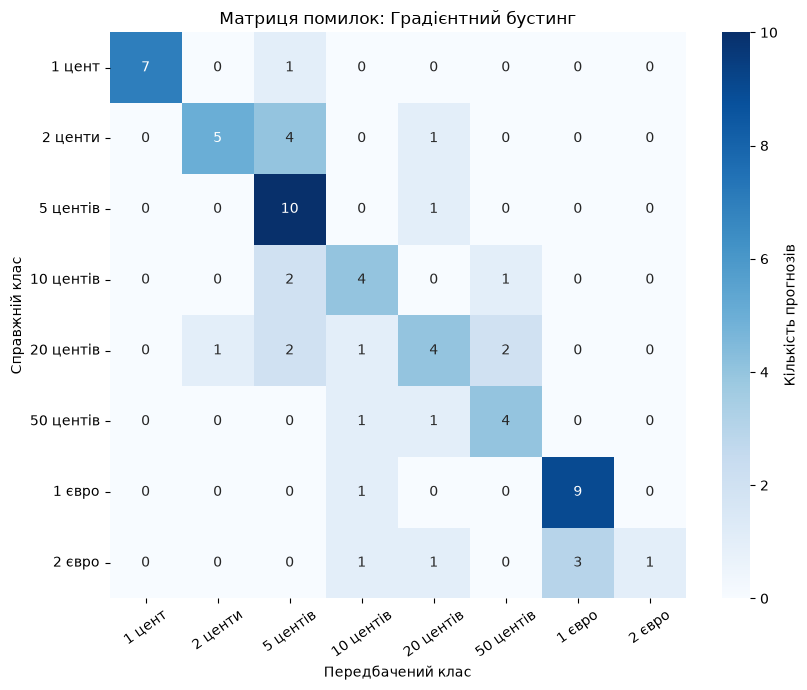

In [19]:
_ = run_notebook_model("Градієнтний бустинг")

## 20. AdaBoostClassifier — адаптивний бустинг

AdaBoost послідовно додає слабкі класифікатори та збільшує увагу до об'єктів, які попередні кроки визначили неправильно. Підсумковий клас отримується зваженим голосуванням. Алгоритм дає змогу перевірити, чи можна покращити прості правила, концентруючись на складних прикладах монет.

Початок навчання: AdaBoost


Час навчання: 2.5834 с
Точність на тестовій вибірці: 0.3235
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.231,0.375,0.286,8.000
2 центи,0.800,0.400,0.533,10.000
5 центів,0.217,0.455,0.294,11.000
10 центів,0.375,0.429,0.400,7.000
20 центів,0.214,0.300,0.250,10.000
50 центів,0.000,0.000,0.000,6.000
1 євро,0.800,0.400,0.533,10.000
2 євро,0.000,0.000,0.000,6.000
загальна точність,0.324,0.324,0.324,0.324
макросереднє,0.330,0.295,0.287,68.000


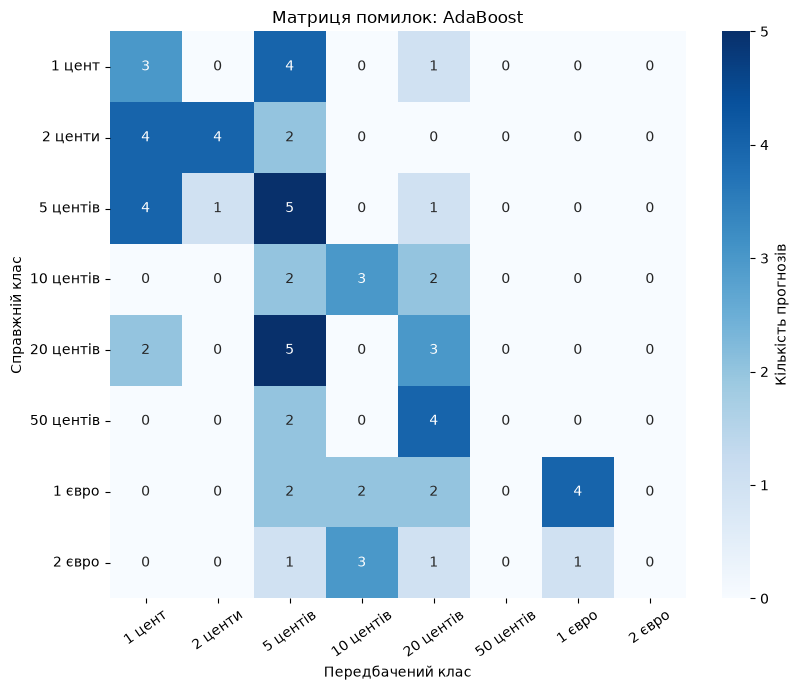

In [20]:
_ = run_notebook_model("AdaBoost")

## 21. GaussianNB — гаусівський наївний Баєс

GaussianNB оцінює для кожного класу розподіл значень ознак як нормальний і припускає їхню умовну незалежність. Для HOG це припущення спрощене, бо сусідні компоненти пов'язані, зате модель навчається дуже швидко. Вона є корисною контрольною точкою для порівняння складніших методів.

Початок навчання: Гаусівський наївний Баєс
Час навчання: 0.0018 с
Точність на тестовій вибірці: 0.6324
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.538,0.875,0.667,8.000
2 центи,1.000,0.500,0.667,10.000
5 центів,0.800,0.727,0.762,11.000
10 центів,0.400,0.571,0.471,7.000
20 центів,0.545,0.600,0.571,10.000
50 центів,0.400,0.333,0.364,6.000
1 євро,0.750,0.900,0.818,10.000
2 євро,1.000,0.333,0.500,6.000
загальна точність,0.632,0.632,0.632,0.632
макросереднє,0.679,0.605,0.602,68.000


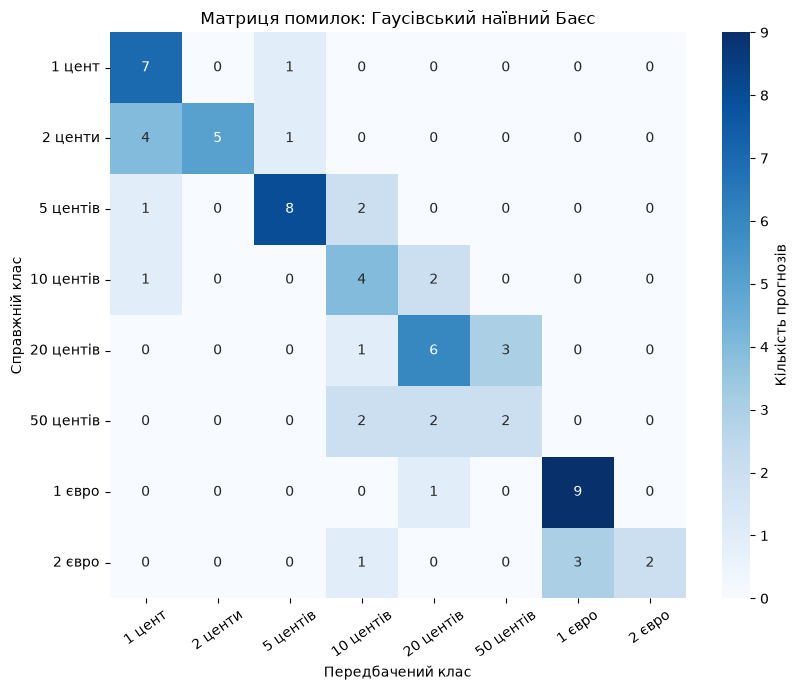

In [21]:
_ = run_notebook_model("Гаусівський наївний Баєс")

## 22. MLPClassifier — багатошаровий перцептрон

MLPClassifier є невеликою класичною нейронною мережею з одним прихованим шаром. Вона комбінує HOG-ознаки через нелінійні перетворення та навчається методом зворотного поширення помилки. Помірний розмір шару, `early_stopping` і фіксований `random_state` обмежують час та ризик перенавчання; TensorFlow або PyTorch тут не використовуються.

Початок навчання: Багатошаровий перцептрон
Час навчання: 0.0608 с
Точність на тестовій вибірці: 0.7500
Класифікаційний звіт:


,точність,повнота,F1-міра,кількість
1 цент,0.667,0.750,0.706,8.00
2 центи,0.889,0.800,0.842,10.00
5 центів,0.900,0.818,0.857,11.00
10 центів,0.857,0.857,0.857,7.00
20 центів,0.875,0.700,0.778,10.00
50 центів,0.714,0.833,0.769,6.00
1 євро,0.667,0.800,0.727,10.00
2 євро,0.333,0.333,0.333,6.00
загальна точність,0.750,0.750,0.750,0.75
макросереднє,0.738,0.736,0.734,68.00


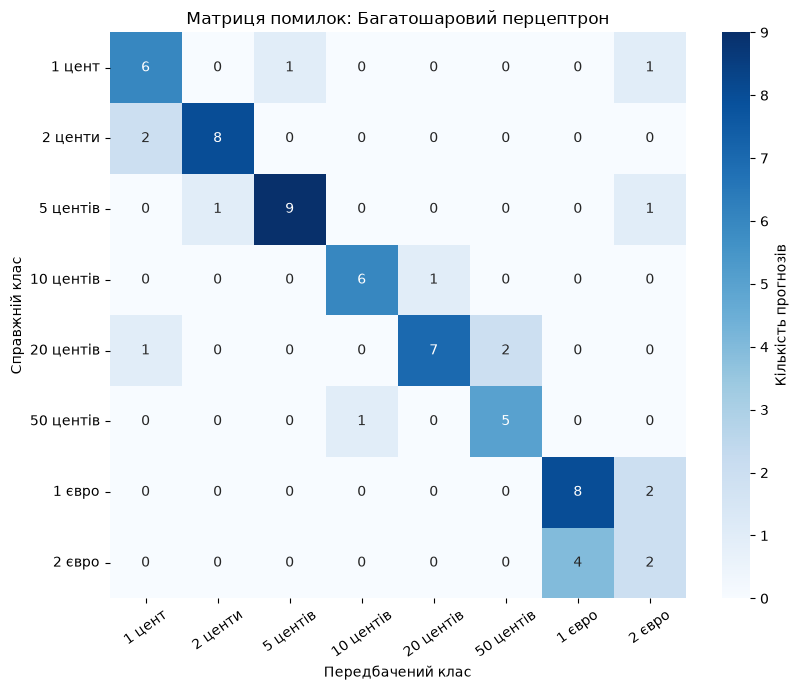

In [22]:
_ = run_notebook_model("Багатошаровий перцептрон")

## 23. Підсумкове порівняння моделей

Результати всіх успішно навчених моделей об'єднуються в одну таблицю та сортуються за accuracy. Окремо зберігається час виконання `fit`, тому можна оцінити не лише якість, а й обчислювальну вартість методу. Внутрішній DataFrame має запитані стовпці `model name`, `accuracy`, `training time`, а для показу в ноутбуці вони перекладаються українською.

,Модель,Точність,"Час навчання, с"
0,Логістична регресія,0.8529,3.4056
1,Надзвичайно рандомізовані дерева,0.7794,0.1402
2,Метод опорних векторів,0.7647,0.0308
3,Випадковий ліс,0.7500,0.2102
4,Багатошаровий перцептрон,0.7500,0.0608
5,Метод k-найближчих сусідів,0.7353,0.0008
6,Градієнтний бустинг,0.6471,23.4908
7,Гаусівський наївний Баєс,0.6324,0.0018
8,Дерево рішень,0.4265,0.1259
9,AdaBoost,0.3235,2.5834


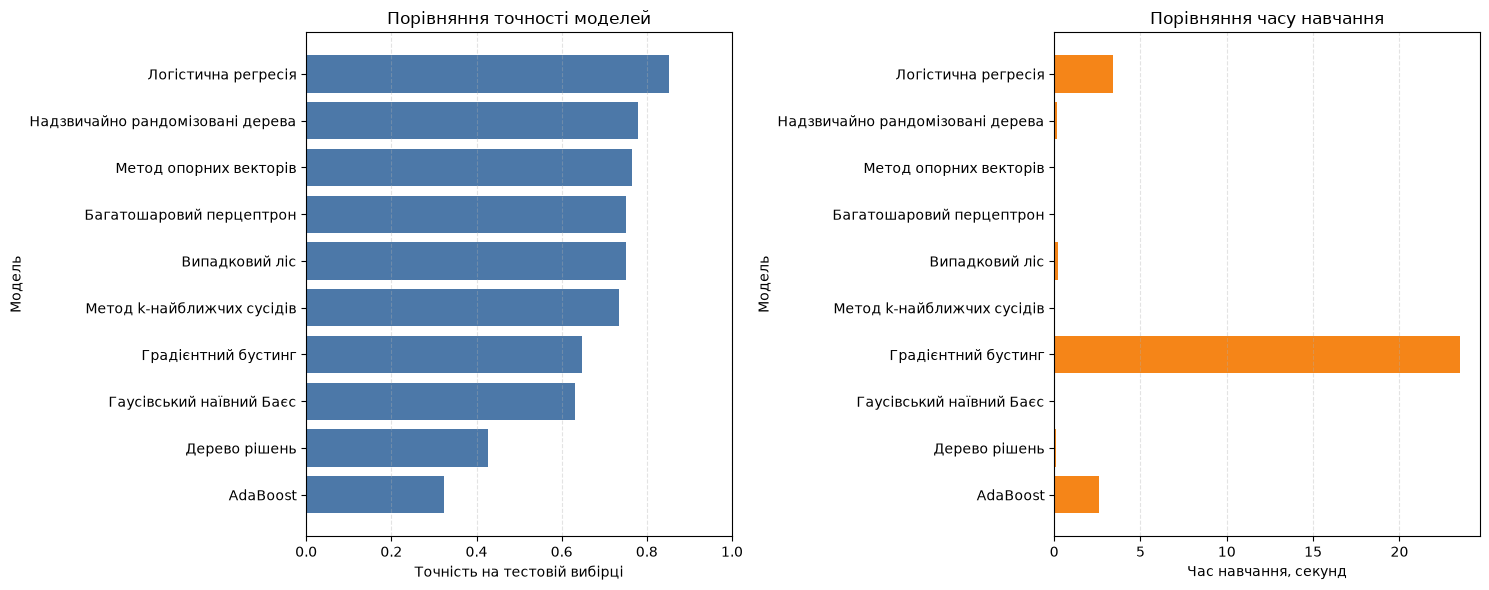

In [23]:
results_df = pd.DataFrame(
    results_rows,
    columns=["model name", "accuracy", "training time"],
).sort_values("accuracy", ascending=False, ignore_index=True)

results_df.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
np.savez(OUTPUT_DIR / "model_predictions.npz", **predictions)

comparison_table = results_df.rename(
    columns={
        "model name": "Модель",
        "accuracy": "Точність",
        "training time": "Час навчання, с",
    }
)
display(
    comparison_table.style.format(
        {"Точність": "{:.4f}", "Час навчання, с": "{:.4f}"}
    )
)

plot_model_comparison(
    results_df,
    save_path=OUTPUT_DIR / "model_comparison.png",
    show=True,
);

## Висновок етапів 2–3

Кропи монет перетворено на HOG-вектори, ознаки нормалізовано, а вибірку стратифіковано поділено на навчальну й тестову частини. Десять класичних алгоритмів порівнюються на однакових даних, тому різниця в accuracy відображає поведінку самих методів, а не інший випадковий поділ. Прогнози збережені у словнику `predictions` і надалі можуть бути використані для t-SNE та аналізу помилок.

In [24]:
if not results_df.empty:
    best_result = results_df.iloc[0]
    print(
        f"Найвищу точність показала модель «{best_result['model name']}»: "
        f"{best_result['accuracy']:.4f}."
    )
    print(
        "Під час інтерпретації результату слід враховувати невеликий розмір "
        "тестової вибірки та дисбаланс між номіналами."
    )
else:
    print("Жодну модель не вдалося навчити; потрібно переглянути повідомлення про помилки.")

Найвищу точність показала модель «Логістична регресія»: 0.8529.
Під час інтерпретації результату слід враховувати невеликий розмір тестової вибірки та дисбаланс між номіналами.


# Етап 4. Фінальна візуалізація та t-SNE аналіз

На завершальному етапі результати впорядковуються в єдину таблицю, а точність і час навчання показуються на окремих діаграмах. Додатково багатовимірні HOG-ознаки тестових монет зменшуються до двох координат методом t-SNE. Це дає змогу візуально оцінити, наскільки добре номінали відокремлюються один від одного та де виникають помилки моделей.

## 24. Фінальна таблиця результатів

Таблиця містить назву моделі, accuracy на тестовій вибірці та час виконання навчання. Рядки сортуються за тестовою точністю у спадному порядку, тому найкращий за основною метрикою алгоритм розташований першим. Час залежить від комп'ютера, але дає корисне відносне порівняння складності методів у межах одного запуску.

In [25]:
from IPython.display import Markdown

from src.final_analysis import (
    build_final_comparison,
    calculate_tsne_embedding,
    select_accuracy_time_balance,
)
from src.visualization import (
    plot_accuracy_comparison,
    plot_training_time_comparison,
    plot_tsne_classes,
)

final_results_df = build_final_comparison(results_df)
final_results_df.to_csv(OUTPUT_DIR / "final_model_comparison.csv", index=False)

final_table_ua = final_results_df.rename(
    columns={
        "model name": "Модель",
        "test accuracy": "Тестова точність",
        "training time": "Час навчання, с",
    }
)
display(
    final_table_ua.style.format(
        {"Тестова точність": "{:.4f}", "Час навчання, с": "{:.4f}"}
    )
)

,Модель,Тестова точність,"Час навчання, с"
0,Логістична регресія,0.8529,3.4056
1,Надзвичайно рандомізовані дерева,0.7794,0.1402
2,Метод опорних векторів,0.7647,0.0308
3,Випадковий ліс,0.7500,0.2102
4,Багатошаровий перцептрон,0.7500,0.0608
5,Метод k-найближчих сусідів,0.7353,0.0008
6,Градієнтний бустинг,0.6471,23.4908
7,Гаусівський наївний Баєс,0.6324,0.0018
8,Дерево рішень,0.4265,0.1259
9,AdaBoost,0.3235,2.5834


## 25. Порівняння точності та часу навчання

Перша діаграма показує частку правильно класифікованих тестових монет: довший стовпчик означає кращу accuracy. Друга діаграма відображає лише час `fit`: коротший стовпчик відповідає швидшому навчанню. Графіки розділені, тому велике значення часу градієнтного бустингу не заважає читати різницю в точності.

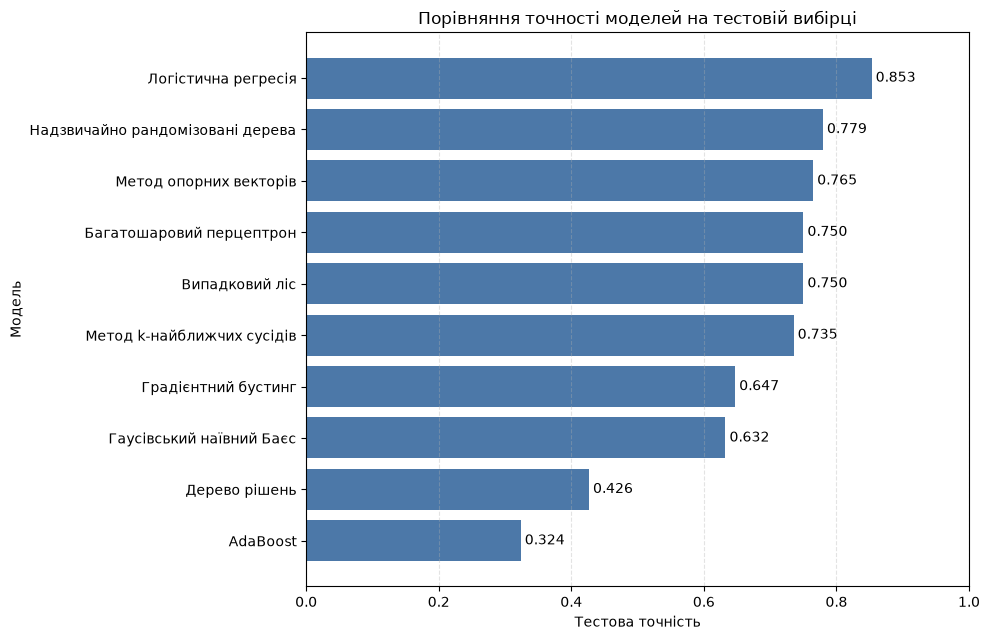

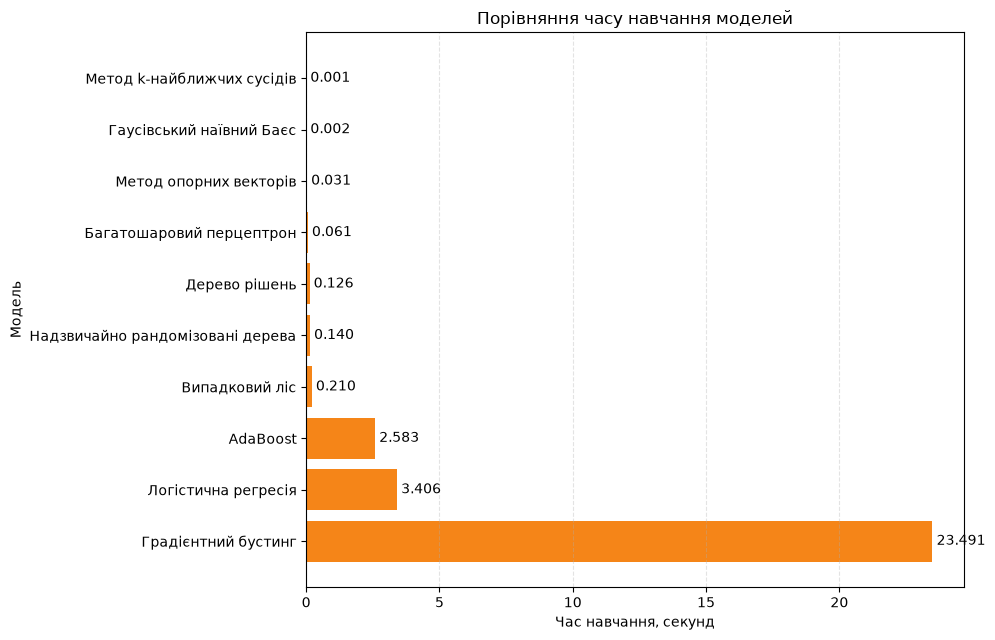

In [26]:
plot_accuracy_comparison(
    final_results_df,
    save_path=OUTPUT_DIR / "final_accuracy_comparison.png",
    show=True,
);

plot_training_time_comparison(
    final_results_df,
    save_path=OUTPUT_DIR / "final_training_time_comparison.png",
    show=True,
);

## 26. Що показує t-SNE

t-SNE — це метод нелінійного зменшення розмірності, який намагається розташувати схожі об'єкти поруч, а несхожі — далі один від одного. Він потрібен тому, що HOG-вектор має 1764 ознаки й людина не може безпосередньо побачити такий простір. Зменшення до двох вимірів дозволяє намалювати кожну тестову монету однією точкою на площині.

На scatter plot колір відповідає класу, а відстань між точками приблизно відображає локальну схожість HOG-описів. Окремі компактні кольорові групи означають, що класи добре розрізняються. Якщо кольори перекриваються, моделі можуть плутати ці номінали. Для монет перекриття природне: різні номінали мають круглу форму, подібні краї та текстури, а освітлення, поворот, фон і сторона монети змінюють вигляд навіть у межах одного класу. Глобальні відстані між далекими групами t-SNE не слід трактувати як точну математичну міру.

In [27]:
tsne_embedding, safe_perplexity = calculate_tsne_embedding(
    prepared_data.X_test,
    random_state=42,
)
np.save(OUTPUT_DIR / "tsne_embedding.npy", tsne_embedding)

print(f"Кількість тестових об'єктів: {len(prepared_data.X_test)}")
print(f"Автоматично обрана безпечна perplexity: {safe_perplexity}")
print(f"Форма двовимірного t-SNE представлення: {tsne_embedding.shape}")

Кількість тестових об'єктів: 68
Автоматично обрана безпечна perplexity: 22
Форма двовимірного t-SNE представлення: (68, 2)


## 27. t-SNE для справжніх класів

Спочатку точки зафарбовуються за правильними мітками з тестової вибірки. Цей графік показує реальну структуру класів у просторі HOG-ознак після зменшення розмірності. Він є еталоном для наступних графіків із прогнозами моделей.

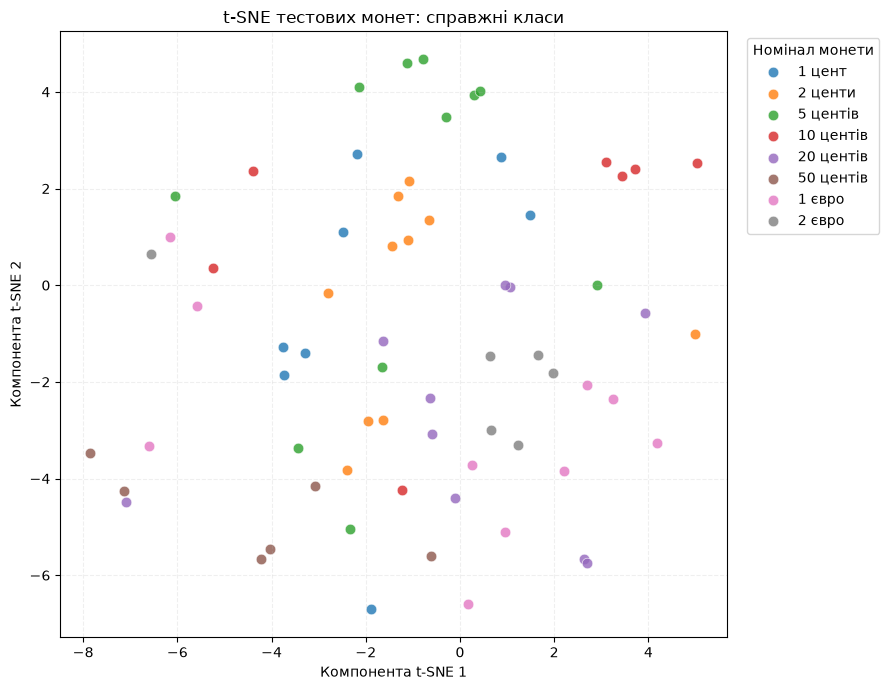

In [28]:
plot_tsne_classes(
    tsne_embedding,
    prepared_data.y_test,
    class_names_ua,
    title="t-SNE тестових монет: справжні класи",
    save_path=OUTPUT_DIR / "tsne" / "true_classes.png",
    show=True,
);

## 28. t-SNE для прогнозів усіх моделей

Координати точок залишаються такими самими, але колір тепер задається прогнозом конкретної моделі. Якщо кольорова структура близька до графіка справжніх класів, модель добре відтворює реальний поділ. Точки зі зміненим кольором відповідають помилкам класифікації. Окремий scatter plot будується для кожної з десяти навчених моделей.

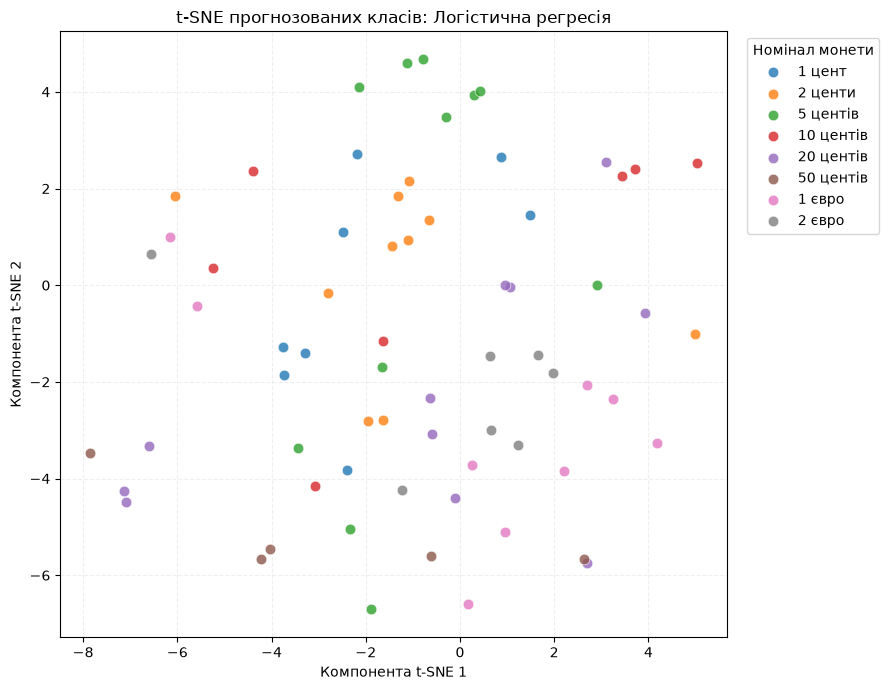

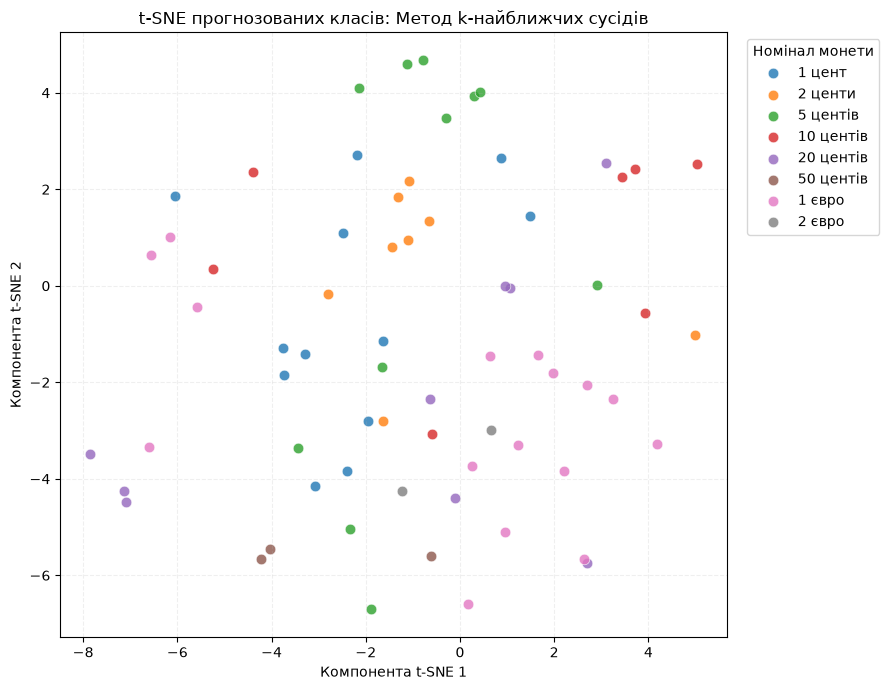

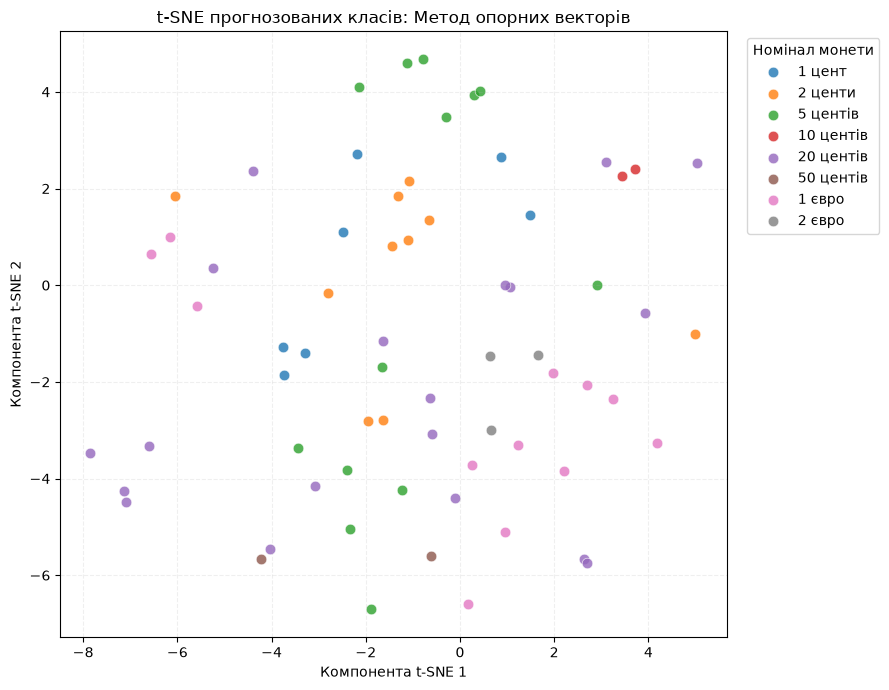

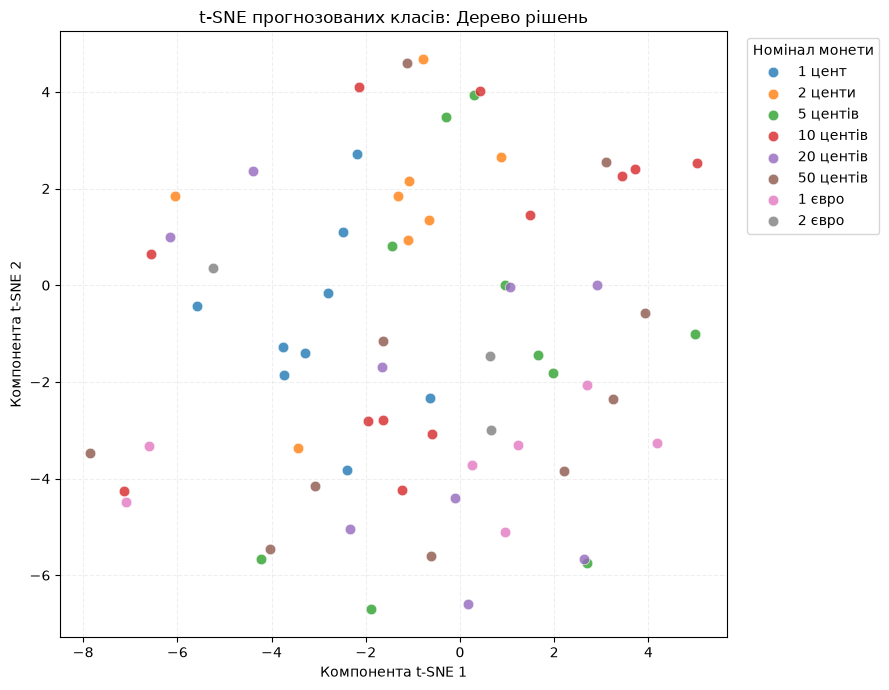

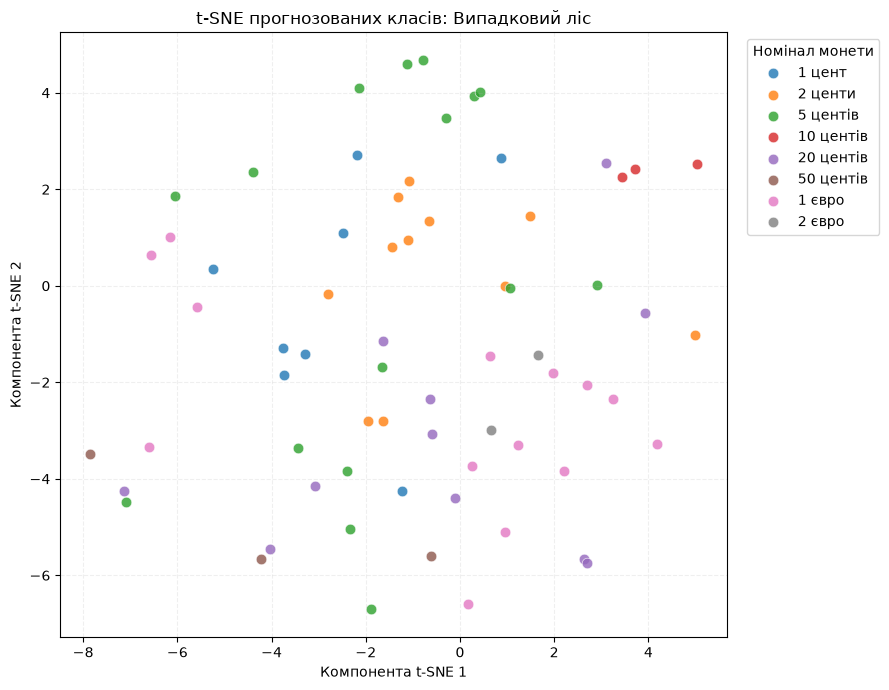

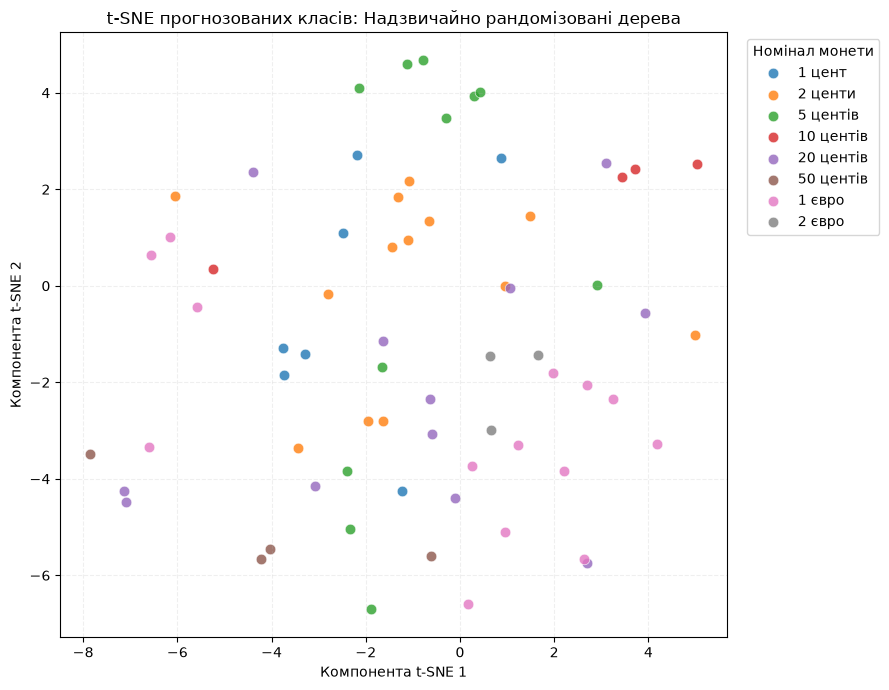

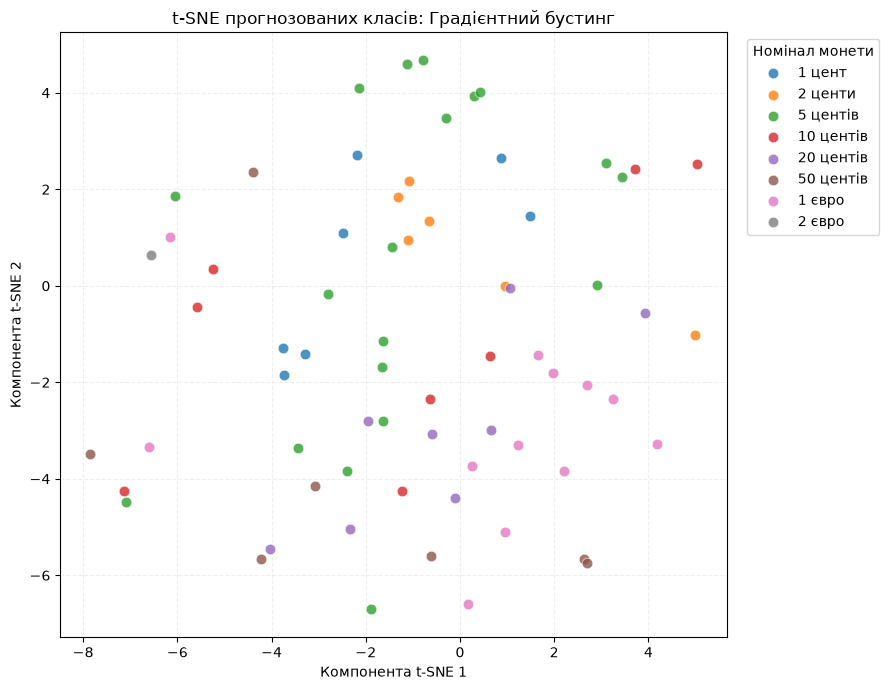

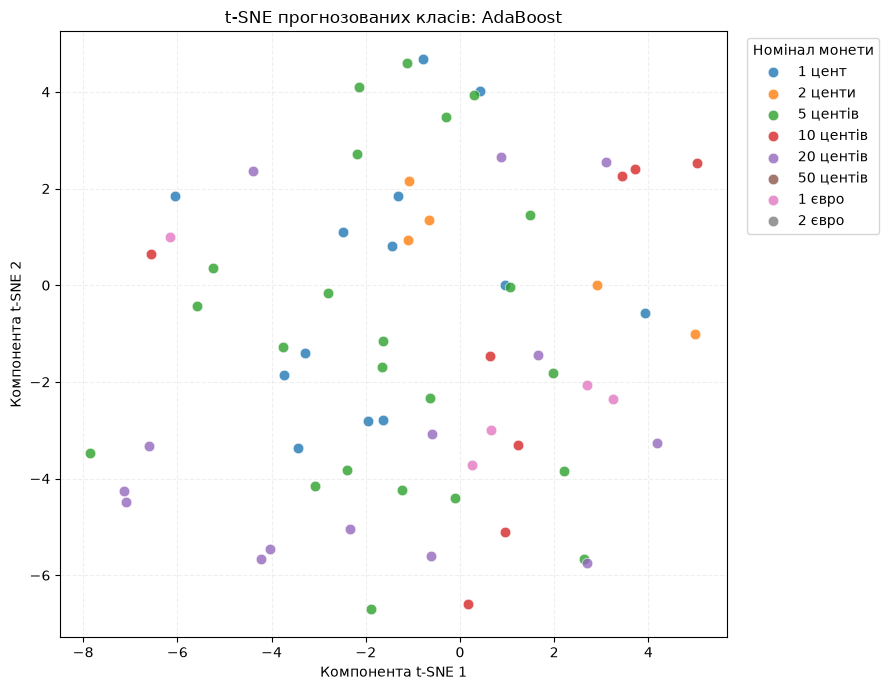

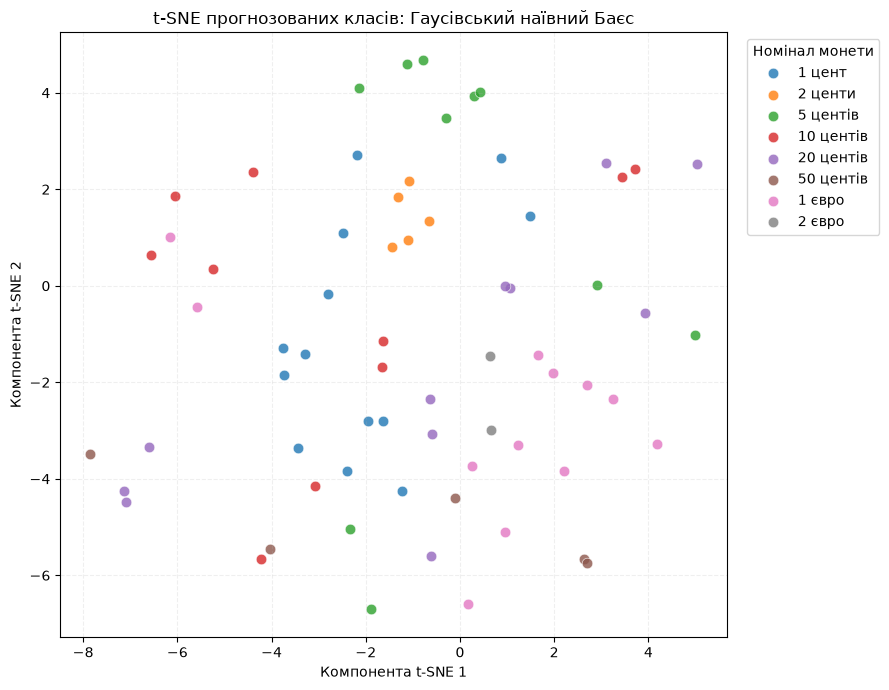

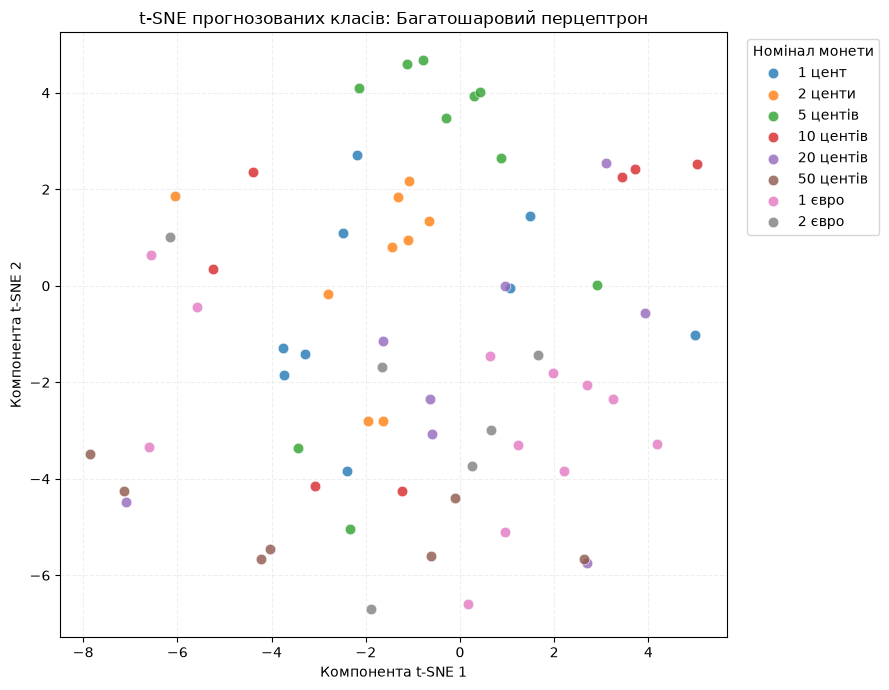

In [29]:
for model_number, model_name in enumerate(models, start=1):
    if model_name not in predictions:
        print(f"Для моделі «{model_name}» немає прогнозів, тому графік пропущено.")
        continue

    plot_tsne_classes(
        tsne_embedding,
        predictions[model_name],
        class_names_ua,
        title=f"t-SNE прогнозованих класів: {model_name}",
        save_path=OUTPUT_DIR / "tsne" / f"model_{model_number:02d}.png",
        show=True,
    )

## 29. Фінальні висновки

Найвищу тестову точність у проведеному експерименті показала **логістична регресія** — приблизно 85,3%. Найменший час власне навчання мав **KNN**, оскільки під час `fit` цей метод переважно запам'ятовує навчальні дані, а основні обчислення переносить на прогнозування. Найкращим практичним балансом за прийнятим правилом став **SVC**: серед моделей, що відстають від лідера не більше ніж на 10 відсоткових пунктів, він навчався найшвидше.

Окреме дерево рішень та AdaBoost спрацювали гірше, оскільки прості деревоподібні правила недостатньо стабільно описують велику кількість пов'язаних HOG-ознак. GaussianNB також обмежений припущенням про незалежність ознак, яке для сусідніх градієнтів не виконується. Результат не є ідеальним через невеликий набір із 336 монет, нерівномірну кількість класів, різне освітлення, положення, повороти та фони зображень.

HOG і класичні алгоритми простіші за CNN та глибоке навчання: вони потребують менше даних, обчислень і часу на налаштування. Водночас HOG добре описує контури цифр, обідка та рельєфу монет, тому такий підхід достатньо обґрунтований для університетського дослідження й дозволяє чесно порівняти багато методів на одному наборі ознак.

In [30]:
best_model = final_results_df.iloc[0]
fastest_model = final_results_df.sort_values("training time").iloc[0]
balanced_model = select_accuracy_time_balance(final_results_df)

display(
    Markdown(
        f"**Перевірка висновків за поточним запуском.** "
        f"Найкраща модель — **{best_model['model name']}** "
        f"із точністю **{best_model['test accuracy']:.4f}**. "
        f"Найшвидше навчалася модель **{fastest_model['model name']}** "
        f"за **{fastest_model['training time']:.4f} с**. "
        f"Найкращий баланс точності й часу за описаним правилом має "
        f"**{balanced_model['model name']}**."
    )
)

**Перевірка висновків за поточним запуском.** Найкраща модель — **Логістична регресія** із точністю **0.8529**. Найшвидше навчалася модель **Метод k-найближчих сусідів** за **0.0008 с**. Найкращий баланс точності й часу за описаним правилом має **Метод опорних векторів**.

# Коротко для захисту

1. У роботі використано набір EURO coins із фотографіями восьми номіналів монет євро.
2. Початково це був набір для детекції об'єктів, тому одна фотографія могла містити кілька монет.
3. Для багатокласової класифікації кожну розмічену монету потрібно було перетворити на окремий приклад.
4. YOLO-анотації містили номер класу та нормалізовані координати центра, ширини й висоти рамки.
5. Координати переводилися в пікселі за фактичним розміром фотографії, після чого монети вирізалися й масштабувалися до `64x64`.
6. Кропи переводилися у відтінки сірого, а з них виділялися розгорнуті пікселі та HOG-ознаки.
7. Основними були HOG-ознаки, бо вони описують напрямки країв, цифри, обідок і рельєф монети.
8. Ознаки нормалізувалися методом `StandardScaler`, щоб їхній масштаб не спотворював KNN, SVM, логістичну регресію та MLP.
9. Дані стратифіковано поділили на 80% для навчання і 20% для тестування.
10. Було навчено десять моделей: Logistic Regression, KNN, SVC, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, AdaBoost, GaussianNB та MLPClassifier.
11. Якість оцінювалася за accuracy, precision, recall і F1-мірою, а також враховувався час навчання.
12. Матриця помилок показує, скільки монет кожного справжнього класу модель віднесла до кожного прогнозованого класу.
13. t-SNE зменшує 1764 HOG-ознаки до двох координат і показує, які номінали утворюють окремі групи, а які перекриваються.
14. Найкращу точність у цьому експерименті показала логістична регресія — близько 85,3%.
15. Підсумковий висновок полягає в тому, що HOG разом із класичними моделями дає добрий і зрозумілий результат для невеликого університетського набору, хоча більший датасет і CNN могли б підвищити точність.